In [7]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#**Video games sales analysis and prediction using machine learning**

### *The dataset contains information about video games including their platform, genre, publisher, review scores, launch prices, and regional sales figures.*

### the goal is to perform a complete data analysis and machine learning workflow on a video games dataset. The finalexpected outcome is to build machine learning models capable of predicting **`global_sales_million`** — the total worldwide sales of a video game in millions of units.



# **Why even bother to predict the global sales?**
- **Game publishers and investors**: Estimating potential revenue before or during development
- **Marketing teams**: Allocating budgets based on expected commercial performance
- **Retailers**: Planning inventory and shelf space
- **Developers**: Understanding what factors drive commercial success

## Problem Type
This is a **Supervised machine learning linear regression problem** because:

-- we already have a labelled training data

-- the target variable **`global_sales_million`** is a continous data rather than a categorical dataset

# **Why even bother to predict the global sales?**
- **Game publishers and investors**: Estimating potential revenue before or during development
- **Marketing teams**: Allocating budgets based on expected commercial performance
- **Retailers**: Planning inventory and shelf space
- **Developers**: Understanding what factors drive commercial success

## Problem Type
This is a **Supervised machine learning linear regression problem** because:

-- we already have a labelled training data

-- the target variable **`global_sales_million`** is a continous data rather than a categorical dataset



## Target variable**`global_sales_million`**  total global sales(in millions)
## Workflow

The project follows this structured pipeline:

1. **Data Loading** — Import and inspect the dataset
2. **Data Understanding** — Examine structure, types, and statistics
3. **Data Cleaning** — Handle missing values, duplicates, and anomalies
4. **Exploratory Data Analysis** — Visualize distributions and relationships
5. **Feature Engineering** — Create meaningful new features
6. **Feature Selection** — Choose relevant predictors while avoiding leakage
7. **Train/Test Split** — Divide data before any preprocessing
8. **Preprocessing** — Build pipelines for numerical and categorical data
9. **Model Training** — Train multiple regression algorithms
10. **Evaluation** — Compare models using MAE, RMSE, and R²
11. **Model Comparison** — Identify the best performer
12. **Feature Importance** — Understand what drives predictions
13. **Conclusions** — Summarize findings and limitations

## import the libraries

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# scikit-learn imports
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# set visualization style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (15, 10)
plt.rcParams['font.size'] = 15

# warnings for cleaner outputs
import warnings
warnings.filterwarnings('ignore')
print("All libraries imported successfully!!")

All libraries imported successfully!!


#**Load and inject data**

In [9]:
# Using the dataset found in your Google Drive
# Note: Ensure the file exists at this path or update it accordingly
try:
    df = pd.read_csv('/content/drive/MyDrive/csvs for ML work notebooks/games.csv')
    print("=" * 60)
    print("FIRST 5 ROWS")
    print("=" * 60)
    display(df.head())
    print("\n" + "=" * 60)
    print("LAST 5 ROWS")
    print("=" * 60)
    display(df.tail())
except FileNotFoundError:
    print("Error: The file path was not found. Please check your Google Drive folder structure.")

FIRST 5 ROWS


,game_id,title,platform,platform_type,platform_maker,platform_generation,genre,year,publisher,developer,...,online_multiplayer,dlc_released,microtransactions,loot_boxes,game_pass_available,vr_support,goty_nominated,goty_won,how_long_to_beat_main_hrs,how_long_to_beat_completionist_hrs
0,G000001,eFootball 2023,Game Boy,Handheld,Nintendo,4,Sports,1990,CD Projekt,Deep Silver,...,1,1,0,0,0,0,0,0,31.8,86.1
1,G000002,Doom 3,Xbox,Console,Microsoft,6,Rhythm,2004,Ubisoft,Ubisoft,...,0,1,1,0,0,0,0,0,13.1,55.4
2,G000003,God of Fire,PC,PC,Various,0,Misc,1988,Microsoft Studios,Microsoft Studios,...,0,0,0,0,0,0,0,0,9.8,20.9
3,G000004,Call of Duty: Rising Sun,Mobile (Android),Mobile,Google,0,Shooter,2017,InXile Entertainment,InXile Entertainment,...,1,1,1,0,0,0,0,0,9.1,44.8
4,G000005,Fortnite 3,Nintendo 64,Console,Nintendo,5,Battle Royale,1999,Naughty Dog,id Software,...,1,0,1,0,0,0,0,0,150.8,322.3



LAST 5 ROWS


,game_id,title,platform,platform_type,platform_maker,platform_generation,genre,year,publisher,developer,...,online_multiplayer,dlc_released,microtransactions,loot_boxes,game_pass_available,vr_support,goty_nominated,goty_won,how_long_to_beat_main_hrs,how_long_to_beat_completionist_hrs
49995,G049996,NBA 2026,NES,Console,Nintendo,3,Sports,2002,Warner Bros. Games,Warner Bros. Games,...,1,1,0,0,0,0,0,0,28.2,87.9
49996,G049997,Kirby's Odyssey,GameCube,Console,Nintendo,6,Platform,2001,Remedy Entertainment,Remedy Entertainment,...,1,1,0,0,0,0,0,0,12.0,34.8
49997,G049998,Baldur's Gate 6,Browser,Browser,Various,0,Role-Playing,2014,Naughty Dog,Larian Studios,...,1,1,0,0,0,0,0,0,58.1,144.4
49998,G049999,Lost Ark 3,PlayStation 5,Console,Sony,9,MMORPG,2021,Larian Studios,Larian Studios,...,1,0,1,1,0,0,0,0,242.7,630.8
49999,G050000,FIFA 2023,Mobile (iOS),Mobile,Apple,0,Sports,2023,Larian Studios,Larian Studios,...,1,0,1,1,0,0,0,0,18.6,48.2


# **Dataset Shape and Columns (Code Cell)**

In [10]:
# Dataset dimensions
print("=" * 60)
print("DATASET DIMENSIONS")
print("=" * 60)
if 'df' in locals():
    print(f"Number of rows: {df.shape[0]}")
    print(f"Number of columns: {df.shape[1]}")
    # Column names
    print("\n" + "=" * 60)
    print("COLUMN NAMES")
    print("=" * 60)
    for i, col in enumerate(df.columns, 1):
        print(f"{i}. {col}")

DATASET DIMENSIONS
Number of rows: 50000
Number of columns: 35

COLUMN NAMES
1. game_id
2. title
3. platform
4. platform_type
5. platform_maker
6. platform_generation
7. genre
8. year
9. publisher
10. developer
11. publisher_region
12. publisher_tier
13. esrb_rating
14. metacritic_score
15. user_score
16. critic_review_count
17. user_review_count
18. na_sales_million
19. eu_sales_million
20. jp_sales_million
21. other_sales_million
22. global_sales_million
23. estimated_revenue_million_usd
24. launch_price_usd
25. is_sequel
26. online_multiplayer
27. dlc_released
28. microtransactions
29. loot_boxes
30. game_pass_available
31. vr_support
32. goty_nominated
33. goty_won
34. how_long_to_beat_main_hrs
35. how_long_to_beat_completionist_hrs


# **Data Type and info(code cells)**

In [39]:
# Data types
print("=" * 60)
print("DATA TYPES")
print("=" * 60)
print(df.dtypes)

# General dataset information
print("\n" + "=" * 60)
print("DATASET INFO")
print("=" * 60)
df.info()

DATA TYPES
game_id                                object
title                                  object
platform                               object
platform_type                          object
platform_maker                         object
platform_generation                     int64
genre                                  object
year                                    int64
publisher                              object
developer                              object
publisher_region                       object
publisher_tier                         object
esrb_rating                            object
metacritic_score                        int64
user_score                            float64
critic_review_count                     int64
user_review_count                       int64
na_sales_million                      float64
eu_sales_million                      float64
jp_sales_million                      float64
other_sales_million                   float64
global_sales_million   

# **Descriptive Statistics (Code Cell)**

In [40]:
# Descriptive statistics for numerical columns
print("=" * 60)
print("DESCRIPTIVE STATISTICS (Numerical)")
print("=" * 60)
display(df.describe().T)

# Descriptive statistics for categorical columns
print("\n" + "=" * 60)
print("DESCRIPTIVE STATISTICS (Categorical)")
print("=" * 60)
display(df.describe(include=['object']).T)

DESCRIPTIVE STATISTICS (Numerical)


,count,mean,std,min,25%,50%,75%,max
platform_generation,50000.0,4.397120,3.256757,0.00,0.00,5.000,7.0000,10.00
year,50000.0,2007.479640,11.673832,1985.00,1998.00,2008.000,2017.0000,2026.00
metacritic_score,50000.0,74.046480,8.626383,37.00,68.00,74.000,80.0000,99.00
user_score,50000.0,7.407888,1.160381,2.20,6.60,7.400,8.2000,10.00
critic_review_count,50000.0,27.290160,26.261779,0.00,11.00,20.000,34.0000,636.00
user_review_count,50000.0,470.612300,894.567299,0.00,91.00,221.000,515.0000,39129.00
na_sales_million,50000.0,11.946759,20.717035,0.03,2.42,5.940,13.4200,769.07
eu_sales_million,50000.0,7.732016,13.477750,0.01,1.51,3.760,8.6325,389.10
jp_sales_million,50000.0,3.370298,7.439700,0.00,0.40,1.210,3.3300,251.21
other_sales_million,50000.0,2.985665,5.634561,0.01,0.54,1.380,3.2600,300.56



DESCRIPTIVE STATISTICS (Categorical)


,count,unique,top,freq
game_id,50000,50000,G049984,1
title,50000,1391,Devil May Ascend,195
platform,50000,33,PC,6305
platform_type,50000,7,Console,24495
platform_maker,50000,8,Nintendo,16815
genre,50000,20,Action,7496
publisher,50000,51,Sega,1560
developer,50000,51,Sega,1355
publisher_region,50000,15,USA,26100
publisher_tier,50000,3,AAA,35374


## **Observations from Initial Inspection:**



*   The dataset contains video game records with numerical, categorical, and binary features.
*   `global_sales_million` is the target variable and is continuous.


*   Regional sales columns (`na_sales_million`, `eu_sales_million`, etc.) are components of global sales and must be excluded from features to prevent data leakage.
*   `estimated_revenue_million_usd` is likely derived from sales and should be evaluated for leakage.


*   The dataset has a mix of review scores, prices, and categorical metadata.








# **Data Quality assessment (because this is Machine Learning. Duhhhhh!)**

In [41]:
# Check for missing values
print("=" * 60)
print("MISSING VALUES ANALYSIS")
print("=" * 60)
missing_count = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing_count, 'Missing Percentage': missing_pct})
display(missing_df[missing_df['Missing Count'] > 0])

# Duplicate analysis
print("\n" + "=" * 60)
print("DUPLICATE ANALYSIS")
print("=" * 60)
print(f"Completely duplicated rows: {df.duplicated().sum()}")

MISSING VALUES ANALYSIS


,Missing Count,Missing Percentage



DUPLICATE ANALYSIS
Completely duplicated rows: 0


## **descision on duplicate datas:**
--the duplicate values are removed as they give no additional information.

--duplicate `game_id` values would indicate data integrity issues and should be investigated.

--Duplicate titles are retained because the same game may legitimately appear on multiple platforms, in different regions, or as re-releases. Removing them would lose valid information.



# **Invalid and Outliers**

In [42]:
print("=" * 60)
print("INVALID VALUES ANALYSIS")
print("=" * 60)

# Check for negative sales
sales_cols = [col for col in df.columns if 'sales' in col.lower()]
for col in sales_cols:
    neg_count = (df[col] < 0).sum()
    print(f"{col}: {neg_count} negative values")

# Check review score ranges
if 'metacritic_score' in df.columns:
    print(f"metacritic_score range: [{df['metacritic_score'].min()}, {df['metacritic_score'].max()}]")

INVALID VALUES ANALYSIS
na_sales_million: 0 negative values
eu_sales_million: 0 negative values
jp_sales_million: 0 negative values
other_sales_million: 0 negative values
global_sales_million: 0 negative values
metacritic_score range: [37, 99]


In [15]:
print("=" * 60)
print("OUTLIER ANALYSIS USING IQR METHOD")
print("=" * 60)

# Select key numerical columns for outlier analysis
outlier_cols = ['global_sales_million', 'metacritic_score', 'user_score',
                'launch_price_usd', 'review_count']

# Filter to only existing columns
outlier_cols = [c for c in outlier_cols if c in df.columns]

outlier_summary = []

for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    outlier_summary.append({
        'Column': col,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Lower Bound': lower_bound,
        'Upper Bound': upper_bound,
        'Outlier Count': len(outliers),
        'Outlier %': f"{len(outliers)/len(df)*100:.2f}%"
    })

outlier_df = pd.DataFrame(outlier_summary)
display(outlier_df)

OUTLIER ANALYSIS USING IQR METHOD


,Column,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier %
0,global_sales_million,5.14,29.29,24.15,-31.085,65.515,4312,8.62%
1,metacritic_score,68.00,80.00,12.00,50.000,98.000,219,0.44%
2,user_score,6.60,8.20,1.60,4.200,10.600,153,0.31%
3,launch_price_usd,19.99,59.99,40.00,-40.010,119.990,0,0.00%


# **Outlier visualisation**

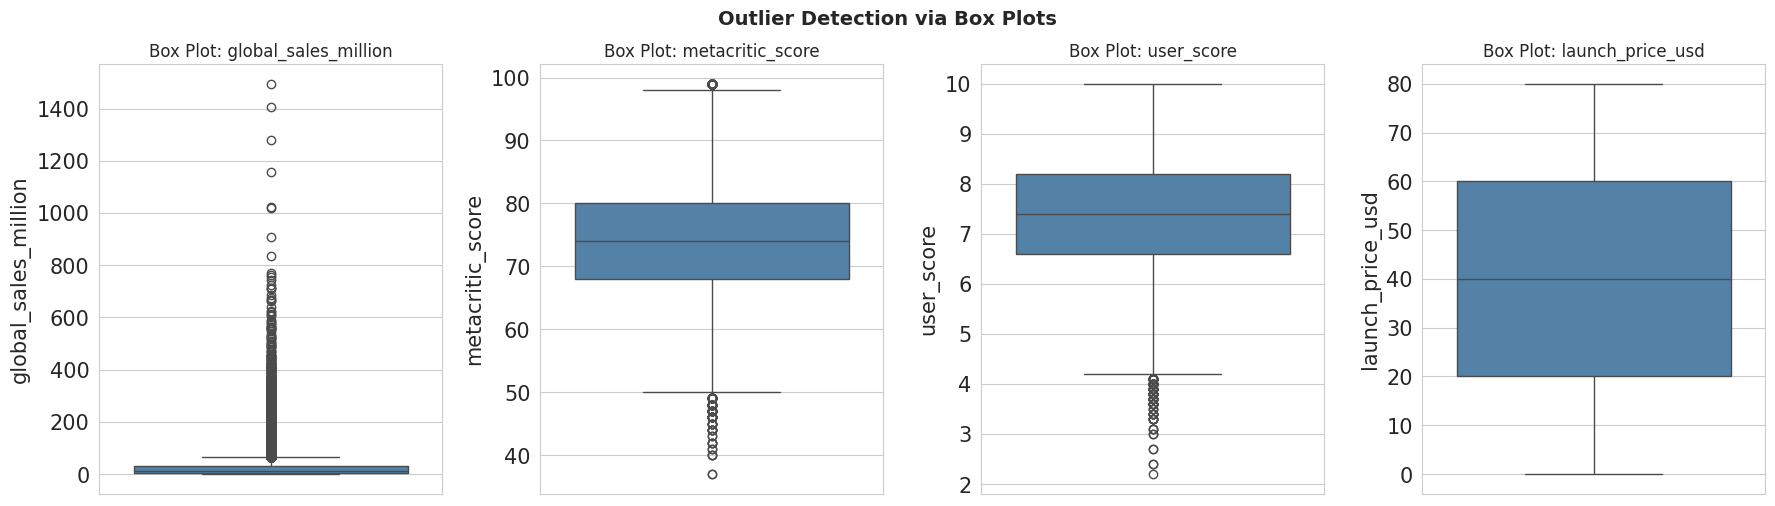

In [16]:
# Box plots to visualize outliers
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

plot_cols = [c for c in ['global_sales_million', 'metacritic_score',
                          'user_score', 'launch_price_usd'] if c in df.columns]

for i, col in enumerate(plot_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='steelblue')
    axes[i].set_title(f'Box Plot: {col}', fontsize=12)
    axes[i].set_ylabel(col)

plt.tight_layout()
plt.suptitle('Outlier Detection via Box Plots', y=1.02, fontsize=14, fontweight='bold')
plt.show()

## **Outlier Decision:**

**We do NOT automatically delete outliers.** Investigation reveals:

**High global sales outliers:** These are legitimate blockbuster games (e.g., Wii Sports, GTA V). They represent real commercial phenomena and are valuable for the model to learn from.

**High metacritic scores:** Legitimate critically-acclaimed games.

**High prices:** Collector's editions or special releases are legitimate.

**Low review counts:** Niche or indie games with limited reviews.

**Conclusion:** All identified outliers appear to be legitimate observations. We retain them. Removing them would bias the model and lose important information about successful games.

# **Exploratory Data Analysis**

##**Distrubution Analyis**

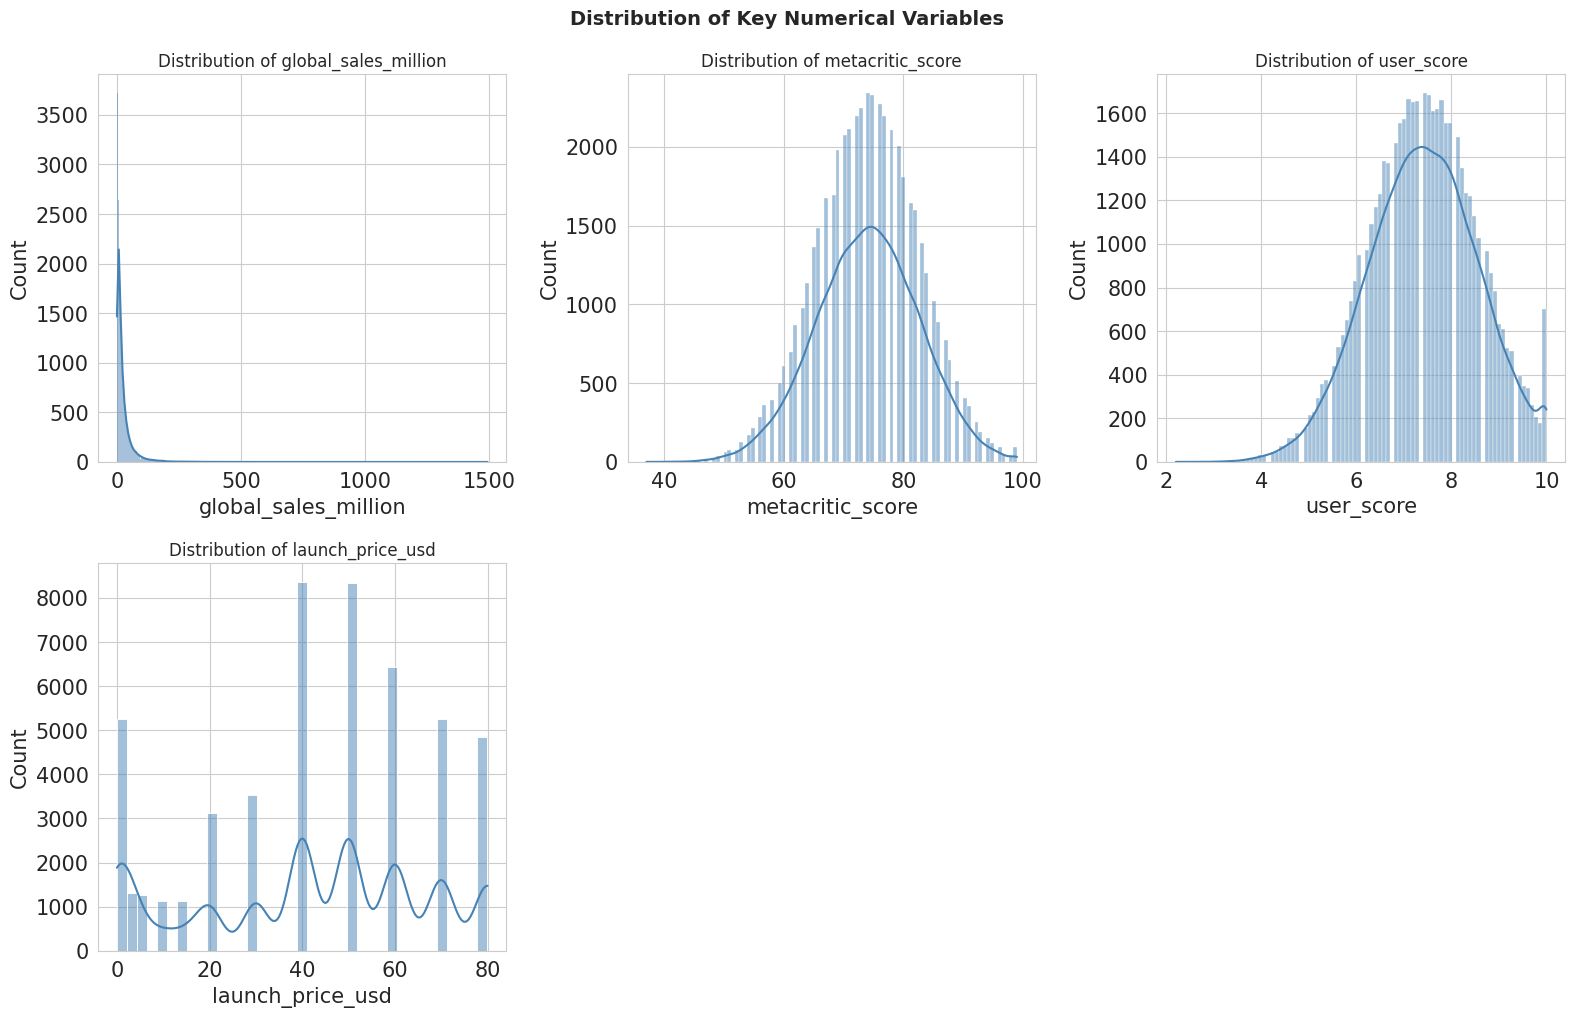

In [17]:
# Distribution of target variable and key numerical features
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

dist_cols = [c for c in ['global_sales_million', 'metacritic_score',
                          'user_score', 'launch_price_usd',
                          'review_count', 'playtime_hours'] if c in df.columns]

for i, col in enumerate(dist_cols):
    row, col_idx = divmod(i, 3)
    sns.histplot(df[col].dropna(), kde=True, ax=axes[row, col_idx], color='steelblue')
    axes[row, col_idx].set_title(f'Distribution of {col}', fontsize=12)
    axes[row, col_idx].set_xlabel(col)

# Hide empty subplots
for j in range(len(dist_cols), 6):
    row, col_idx = divmod(j, 3)
    axes[row, col_idx].set_visible(False)

plt.tight_layout()
plt.suptitle('Distribution of Key Numerical Variables', y=1.02, fontsize=14, fontweight='bold')
plt.show()

##**Categorical Analysis:**

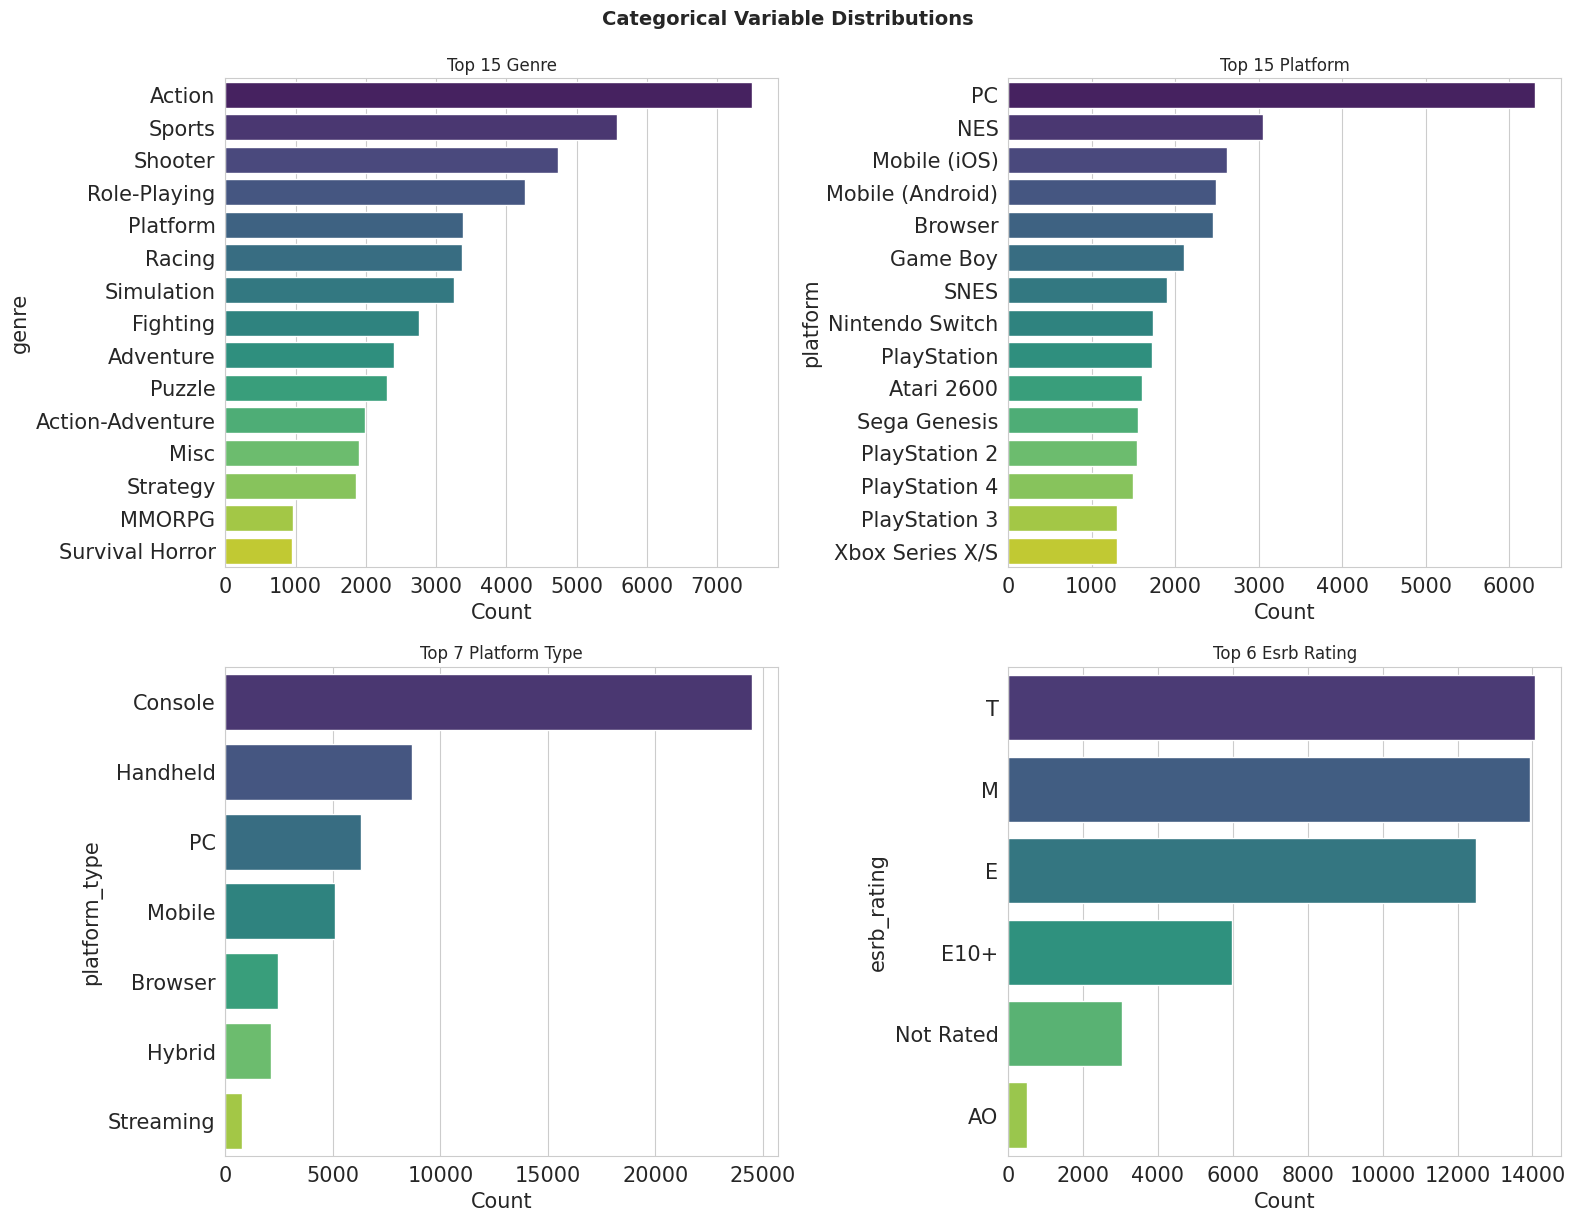

In [18]:
# Categorical distributions
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

cat_cols = [c for c in ['genre', 'platform', 'platform_type', 'esrb_rating']
            if c in df.columns]

for i, col in enumerate(cat_cols):
    row, col_idx = divmod(i, 2)
    top_n = df[col].value_counts().head(15)
    sns.barplot(x=top_n.values, y=top_n.index, ax=axes[row, col_idx], palette='viridis')
    axes[row, col_idx].set_title(f'Top {len(top_n)} {col.replace("_", " ").title()}', fontsize=12)
    axes[row, col_idx].set_xlabel('Count')

plt.tight_layout()
plt.suptitle('Categorical Variable Distributions', y=1.02, fontsize=14, fontweight='bold')
plt.show()

##**Publisher Report Analysis:**

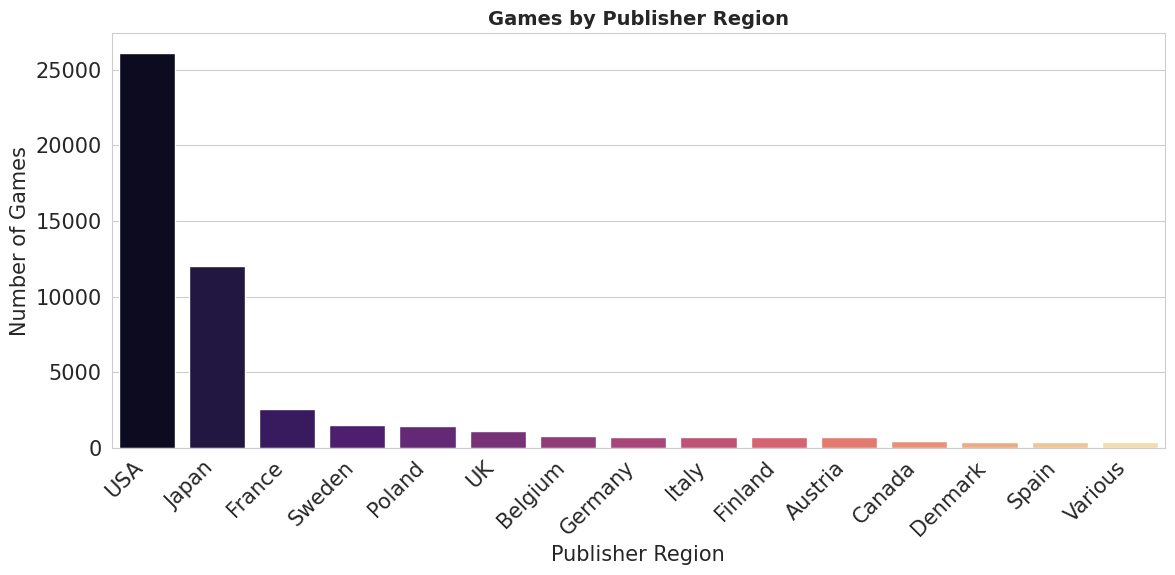

In [19]:
# Publisher region distribution
if 'publisher_region' in df.columns:
    plt.figure(figsize=(12, 6))
    region_counts = df['publisher_region'].value_counts()
    sns.barplot(x=region_counts.index, y=region_counts.values, palette='magma')
    plt.title('Games by Publisher Region', fontsize=14, fontweight='bold')
    plt.xlabel('Publisher Region')
    plt.ylabel('Number of Games')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

## **Top 10 Best-Sellers:**

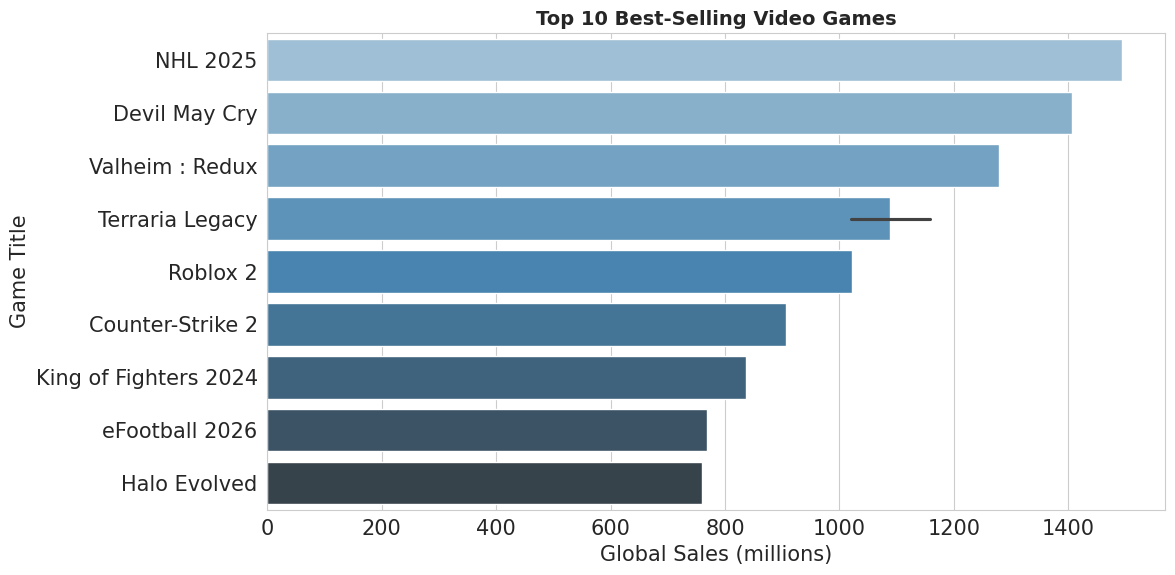

,title,platform,global_sales_million
17200,NHL 2025,Mobile (Android),1494.68
414,Devil May Cry,Mobile (Android),1407.66
4510,Valheim : Redux,Mobile (Android),1279.62
5352,Terraria Legacy,Mobile (iOS),1157.95
38695,Roblox 2,Xbox Series X/S,1022.34
28804,Terraria Legacy,Xbox 360,1019.81
23280,Counter-Strike 2,Mobile (Android),906.09
45682,King of Fighters 2024,Mobile (Android),836.24
48360,eFootball 2026,PlayStation 5,769.18
18251,Halo Evolved,Mobile (Android),760.50


In [20]:
# Top 10 best-selling games
if 'title' in df.columns and 'global_sales_million' in df.columns:
    top_games = df.nlargest(10, 'global_sales_million')[['title', 'platform', 'global_sales_million']]

    plt.figure(figsize=(12, 6))
    sns.barplot(data=top_games, x='global_sales_million', y='title', palette='Blues_d')
    plt.title('Top 10 Best-Selling Video Games', fontsize=14, fontweight='bold')
    plt.xlabel('Global Sales (millions)')
    plt.ylabel('Game Title')
    plt.tight_layout()
    plt.show()

    display(top_games)

## **Sales by Genre:**

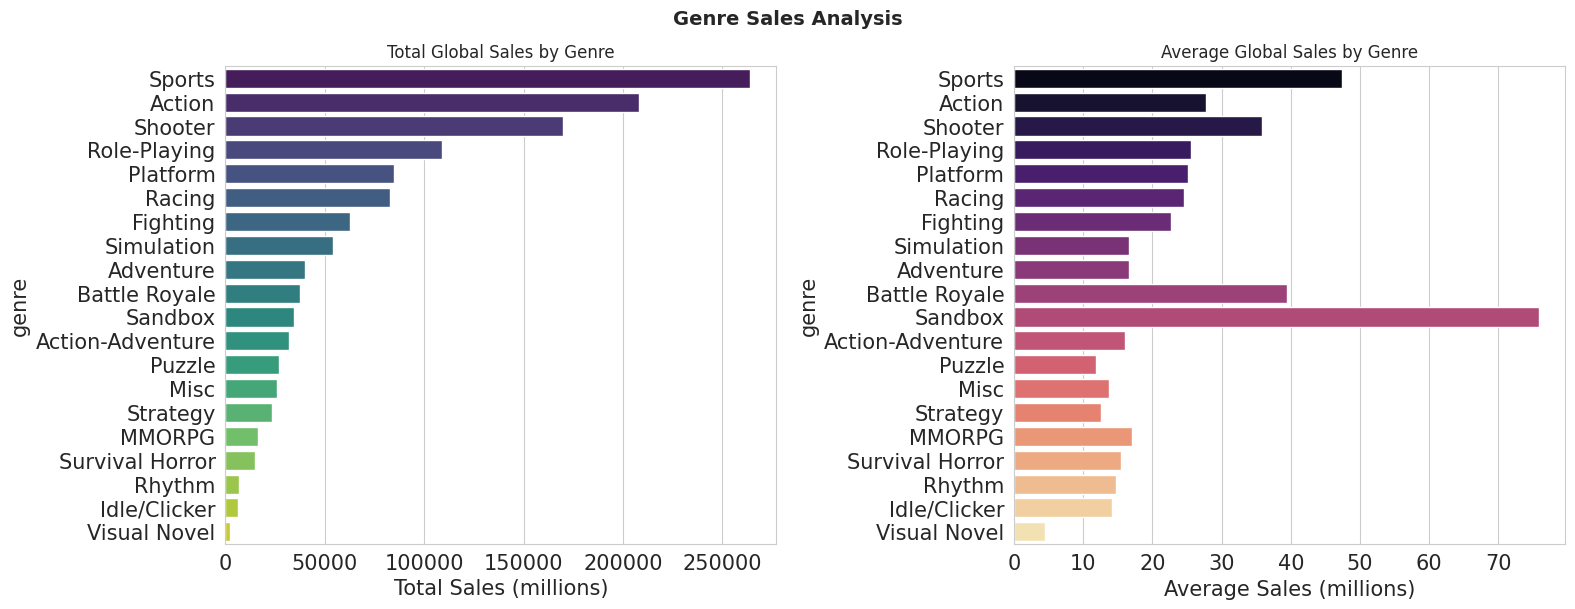

,mean,sum,count
genre,,,
Sports,47.359330,263838.83,5571
Action,27.774537,208197.93,7496
Shooter,35.834448,169891.12,4741
Role-Playing,25.536414,108963.88,4267
Platform,25.119622,85004.80,3384
Racing,24.546227,82745.33,3371
Fighting,22.646103,62525.89,2761
Simulation,16.613567,53977.48,3249
Adventure,16.646053,39900.59,2397


In [21]:
# Average and total sales by genre
if 'genre' in df.columns:
    genre_sales = df.groupby('genre')['global_sales_million'].agg(['mean', 'sum', 'count']).sort_values('sum', ascending=False)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Total sales by genre
    sns.barplot(x=genre_sales['sum'].values, y=genre_sales.index, ax=axes[0], palette='viridis')
    axes[0].set_title('Total Global Sales by Genre', fontsize=12)
    axes[0].set_xlabel('Total Sales (millions)')

    # Average sales by genre
    sns.barplot(x=genre_sales['mean'].values, y=genre_sales.index, ax=axes[1], palette='magma')
    axes[1].set_title('Average Global Sales by Genre', fontsize=12)
    axes[1].set_xlabel('Average Sales (millions)')

    plt.tight_layout()
    plt.suptitle('Genre Sales Analysis', y=1.02, fontsize=14, fontweight='bold')
    plt.show()

    display(genre_sales)

## **Sales by platform:**

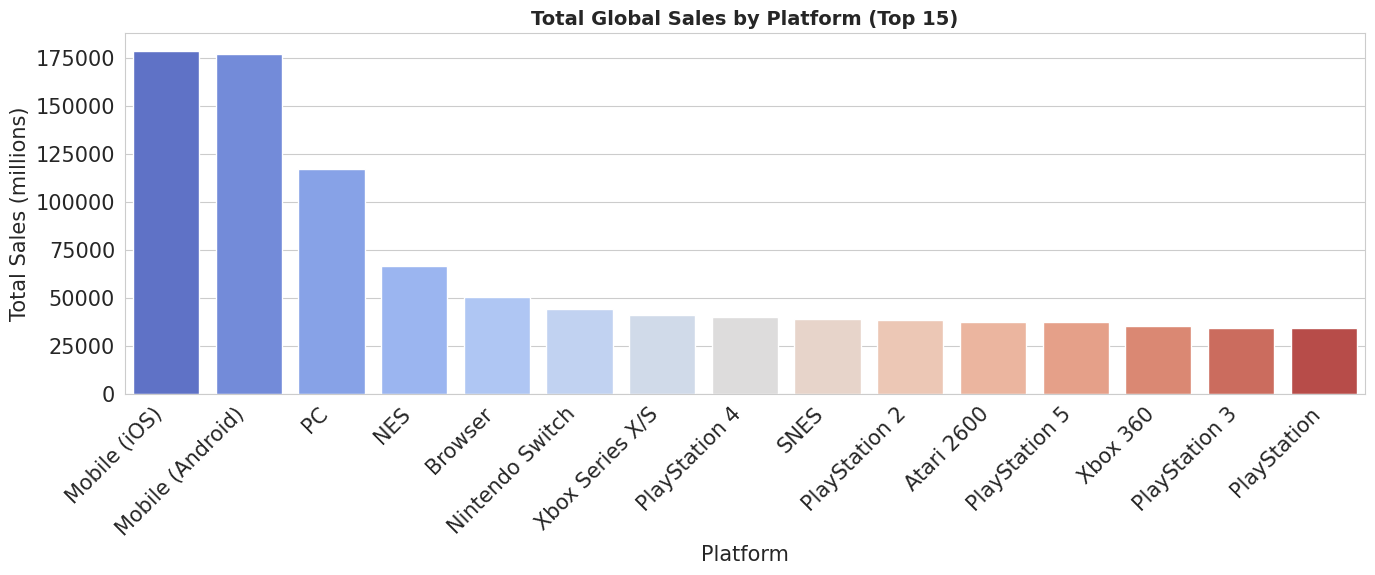

,mean,sum,count
platform,,,
Mobile (iOS),68.186602,178785.27,2622
Mobile (Android),71.310338,177063.57,2483
PC,18.533313,116852.54,6305
NES,21.872969,66603.19,3045
Browser,20.506802,50344.20,2455
Nintendo Switch,25.496995,44288.28,1737
Xbox Series X/S,31.705354,41216.96,1300
PlayStation 4,26.823016,40019.94,1492
SNES,20.368856,38823.04,1906


In [22]:
# Average sales by platform
if 'platform' in df.columns:
    platform_sales = df.groupby('platform')['global_sales_million'].agg(['mean', 'sum', 'count']).sort_values('sum', ascending=False).head(15)

    plt.figure(figsize=(14, 6))
    sns.barplot(x=platform_sales.index, y=platform_sales['sum'].values, palette='coolwarm')
    plt.title('Total Global Sales by Platform (Top 15)', fontsize=14, fontweight='bold')
    plt.xlabel('Platform')
    plt.ylabel('Total Sales (millions)')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

    display(platform_sales)

## **Sales Over time**

In [23]:
# Sales over time
if 'release_year' in df.columns:
    yearly_sales = df.groupby('release_year')['global_sales_million'].agg(['sum', 'mean', 'count']).reset_index()

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Total sales per year
    axes[0].plot(yearly_sales['release_year'], yearly_sales['sum'], marker='o', color='steelblue')
    axes[0].set_title('Total Global Sales by Release Year', fontsize=12)
    axes[0].set_xlabel('Release Year')
    axes[0].set_ylabel('Total Sales (millions)')
    axes[0].grid(True, alpha=0.3)

    # Number of games per year
    axes[1].bar(yearly_sales['release_year'], yearly_sales['count'], color='coral')
    axes[1].set_title('Number of Games Released per Year', fontsize=12)
    axes[1].set_xlabel('Release Year')
    axes[1].set_ylabel('Number of Games')

    plt.tight_layout()
    plt.suptitle('Sales Trends Over Time', y=1.02, fontsize=14, fontweight='bold')
    plt.show()

## **Relatonship Analysis:**

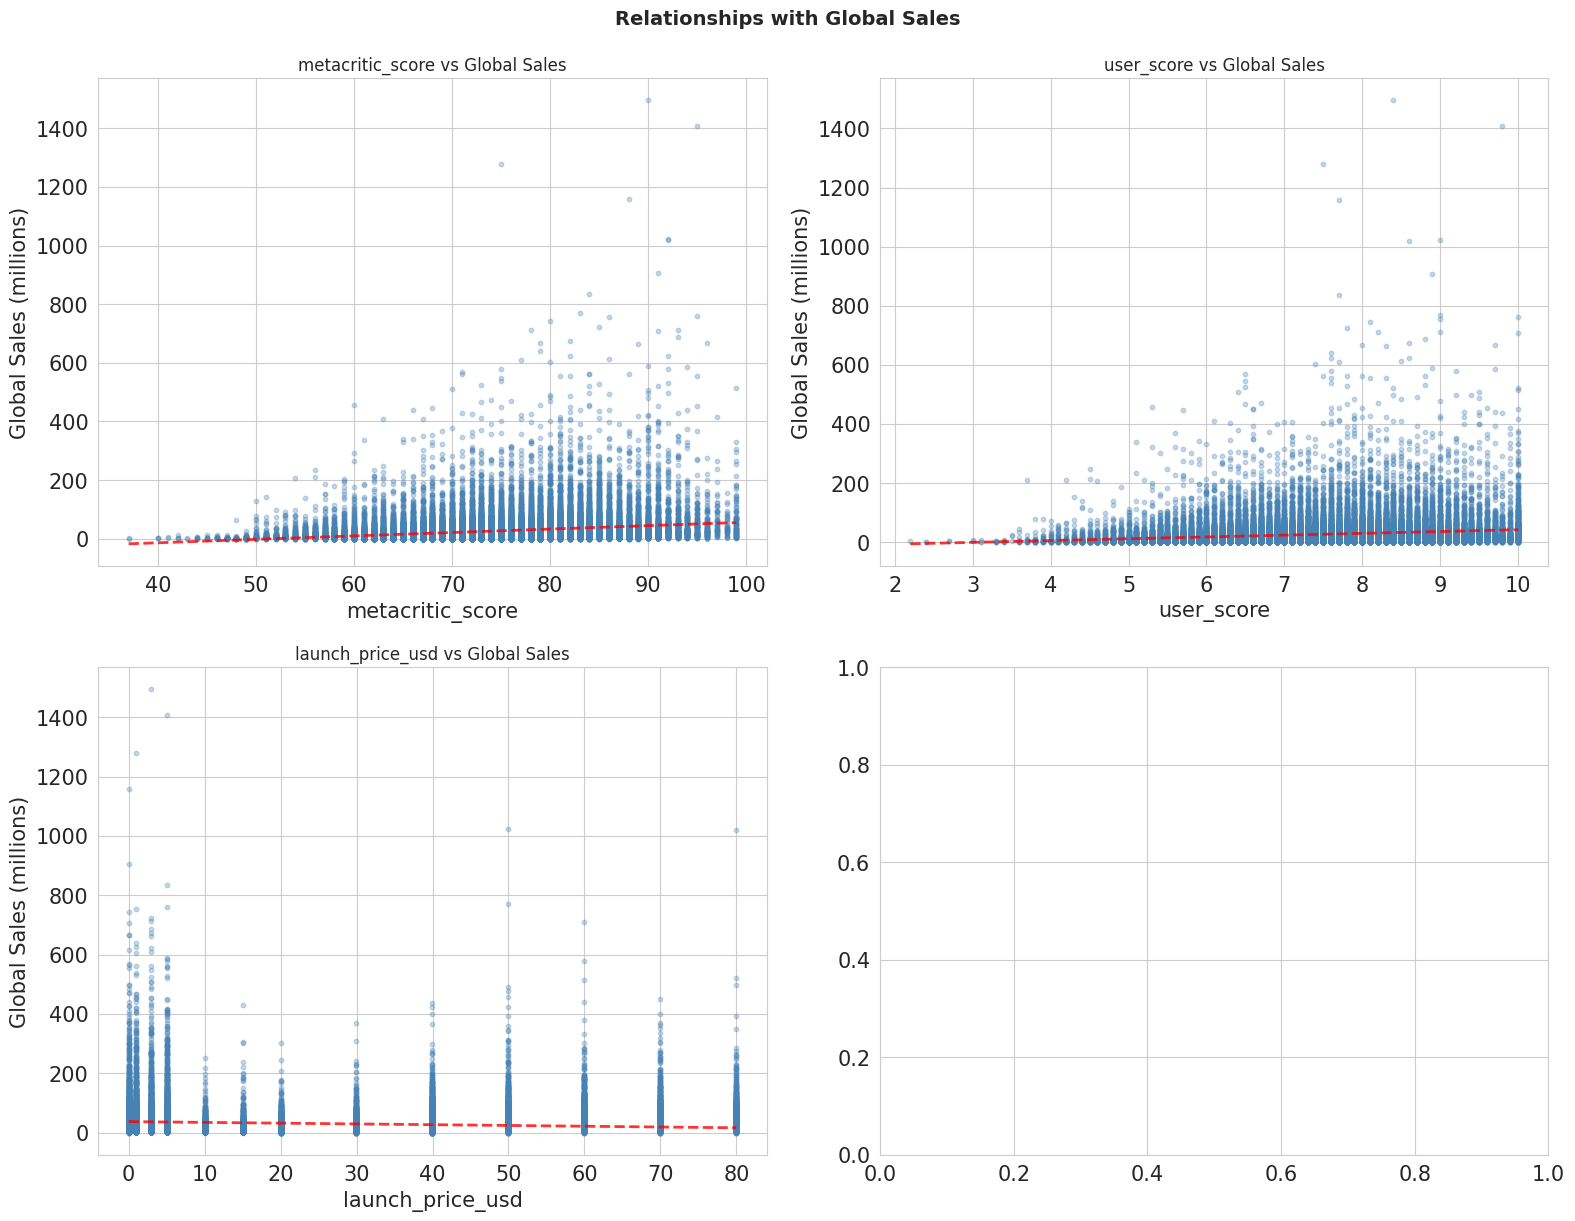

In [24]:
# Scatter plots: relationships with global sales
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

rel_cols = [c for c in ['metacritic_score', 'user_score',
                         'review_count', 'launch_price_usd'] if c in df.columns]

for i, col in enumerate(rel_cols):
    row, col_idx = divmod(i, 2)
    axes[row, col_idx].scatter(df[col], df['global_sales_million'], alpha=0.3, s=10, color='steelblue')
    axes[row, col_idx].set_xlabel(col)
    axes[row, col_idx].set_ylabel('Global Sales (millions)')
    axes[row, col_idx].set_title(f'{col} vs Global Sales', fontsize=12)

    # Add trend line
    if df[col].notna().sum() > 1:
        z = np.polyfit(df[col].dropna(), df.loc[df[col].notna(), 'global_sales_million'], 1)
        p = np.poly1d(z)
        x_range = np.linspace(df[col].min(), df[col].max(), 100)
        axes[row, col_idx].plot(x_range, p(x_range), 'r--', alpha=0.8, linewidth=2)

plt.tight_layout()
plt.suptitle('Relationships with Global Sales', y=1.02, fontsize=14, fontweight='bold')
plt.show()

## **Correlation analysis:**

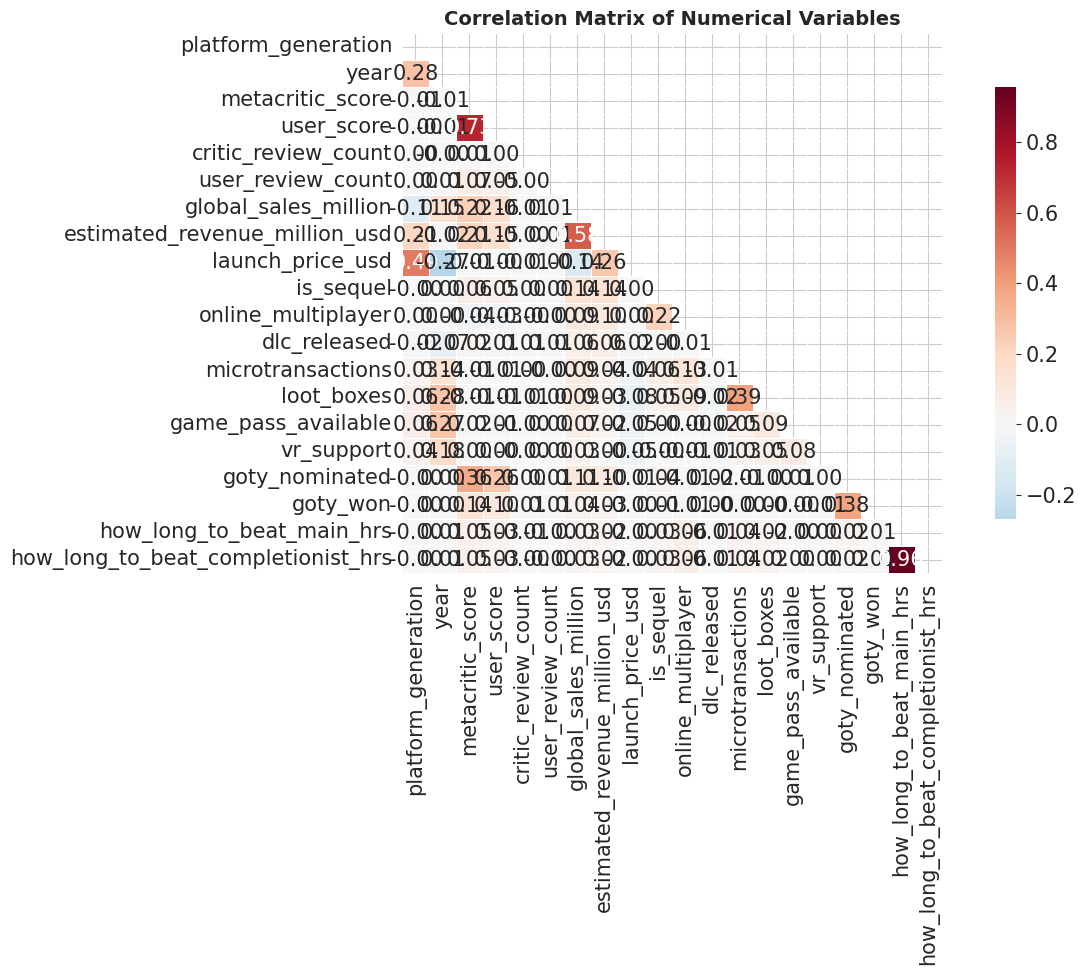


Correlations with global_sales_million:


,global_sales_million
estimated_revenue_million_usd,0.576726
metacritic_score,0.224012
user_score,0.157384
year,0.150674
is_sequel,0.140000
goty_nominated,0.107163
online_multiplayer,0.094460
loot_boxes,0.090743
microtransactions,0.085319
game_pass_available,0.065344


In [25]:
# Correlation matrix for numerical variables only
# Exclude regional sales columns to avoid leakage confusion in analysis
exclude_from_corr = ['game_id', 'na_sales_million', 'eu_sales_million',
                     'jp_sales_million', 'other_sales_million']

numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
corr_cols = [c for c in numerical_cols if c not in exclude_from_corr and c in df.columns]

if len(corr_cols) > 1:
    corr_matrix = df[corr_cols].corr()

    plt.figure(figsize=(14, 10))
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
                cmap='RdBu_r', center=0, square=True,
                linewidths=0.5, cbar_kws={'shrink': 0.8})
    plt.title('Correlation Matrix of Numerical Variables', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Show correlations with target
    if 'global_sales_million' in corr_matrix.columns:
        print("\nCorrelations with global_sales_million:")
        target_corr = corr_matrix['global_sales_million'].drop('global_sales_million').sort_values(ascending=False)
        display(target_corr)

# **Feature Analysis**

## **Create new features**

In [26]:
# Create a copy for feature engineering
df_fe = df.copy()

# 1. Game Age (based on release year)
if 'release_year' in df_fe.columns:
    current_year = 2024
    df_fe['game_age'] = current_year - df_fe['release_year']
    print("Created: game_age = 2024 - release_year")

# 2. Score Difference (metacritic - user score scaled to same range)
if 'metacritic_score' in df_fe.columns and 'user_score' in df_fe.columns:
    # Scale user_score (0-10) to 0-100 to match metacritic
    df_fe['score_difference'] = df_fe['metacritic_score'] - (df_fe['user_score'] * 10)
    print("Created: score_difference = metacritic_score - (user_score * 10)")

# 3. Average Score
if 'metacritic_score' in df_fe.columns and 'user_score' in df_fe.columns:
    df_fe['average_score'] = (df_fe['metacritic_score'] + (df_fe['user_score'] * 10)) / 2
    print("Created: average_score = (metacritic_score + user_score*10) / 2")

# 4. Review engagement (reviews per year of age)
if 'review_count' in df_fe.columns and 'game_age' in df_fe.columns:
    df_fe['reviews_per_year'] = df_fe['review_count'] / (df_fe['game_age'] + 1)
    print("Created: reviews_per_year = review_count / (game_age + 1)")

# 5. Price category (binned launch price)
if 'launch_price_usd' in df_fe.columns:
    df_fe['price_category'] = pd.cut(df_fe['launch_price_usd'],
                                      bins=[0, 20, 40, 60, 100, 1000],
                                      labels=['Budget', 'Low', 'Standard', 'Premium', 'Collector'])
    print("Created: price_category (binned launch_price_usd)")

print("\n" + "=" * 60)
print("FEATURE ENGINEERING SUMMARY")
print("=" * 60)
print("New features created:")
print("  - game_age")
print("  - score_difference")
print("  - average_score")
print("  - reviews_per_year")
print("  - price_category")

print("\nData leakage check:")
print("  ✓ None of the new features use global_sales_million")
print("  ✓ None use regional sales columns")
print("  ✓ All are derived from independent variables")

Created: score_difference = metacritic_score - (user_score * 10)
Created: average_score = (metacritic_score + user_score*10) / 2
Created: price_category (binned launch_price_usd)

FEATURE ENGINEERING SUMMARY
New features created:
  - game_age
  - score_difference
  - average_score
  - reviews_per_year
  - price_category

Data leakage check:
  ✓ None of the new features use global_sales_million
  ✓ None use regional sales columns
  ✓ All are derived from independent variables


## **Leakage-Prone features to exclude:**

In [27]:
print("=" * 60)
print("FEATURES EXCLUDED TO PREVENT DATA LEAKAGE")
print("=" * 60)

leakage_features = {
    'na_sales_million': 'Component of global sales (NA portion)',
    'eu_sales_million': 'Component of global sales (EU portion)',
    'jp_sales_million': 'Component of global sales (JP portion)',
    'other_sales_million': 'Component of global sales (other regions)',
    'estimated_revenue_million_usd': 'Derived from sales figures (revenue = sales × price)',
}

for feat, reason in leakage_features.items():
    if feat in df.columns:
        print(f"  ✗ {feat}: {reason}")
    else:
        print(f"  - {feat}: (not in dataset)")

print("\nThese features are EXCLUDED from X because:")
print("  1. Regional sales are literally components that sum to global sales")
print("  2. Using them would be like predicting a total from its parts")
print("  3. The model would achieve artificially high R² without learning anything useful")
print("  4. In a real prediction scenario, you wouldn't know regional sales before global sales")

FEATURES EXCLUDED TO PREVENT DATA LEAKAGE
  ✗ na_sales_million: Component of global sales (NA portion)
  ✗ eu_sales_million: Component of global sales (EU portion)
  ✗ jp_sales_million: Component of global sales (JP portion)
  ✗ other_sales_million: Component of global sales (other regions)
  ✗ estimated_revenue_million_usd: Derived from sales figures (revenue = sales × price)

These features are EXCLUDED from X because:
  1. Regional sales are literally components that sum to global sales
  2. Using them would be like predicting a total from its parts
  3. The model would achieve artificially high R² without learning anything useful
  4. In a real prediction scenario, you wouldn't know regional sales before global sales


# Feature Selection:

## **Define X and Y axes**

In [28]:
# Define target variable
y = df_fe['global_sales_million'].copy()
print(f"Target variable: global_sales_million")
print(f"  Range: [{y.min():.2f}, {y.max():.2f}]")
print(f"  Mean: {y.mean():.2f}")
print(f"  Median: {y.median():.2f}")

# Define features to EXCLUDE
exclude_cols = [
    'global_sales_million',      # Target
    'game_id',                    # Identifier, no predictive value
    'title',                      # Identifier, too many unique values
    'na_sales_million',           # Leakage
    'eu_sales_million',           # Leakage
    'jp_sales_million',           # Leakage
    'other_sales_million',        # Leakage
    'estimated_revenue_million_usd',  # Leakage
]

# Select feature columns
feature_cols = [c for c in df_fe.columns if c not in exclude_cols]

# Separate numerical and categorical features
numerical_features = df_fe[feature_cols].select_dtypes(include=[np.number]).columns.tolist()
categorical_features = df_fe[feature_cols].select_dtypes(include=['object', 'category']).columns.tolist()

print("\n" + "=" * 60)
print("FEATURE SELECTION SUMMARY")
print("=" * 60)
print(f"\nNumerical features ({len(numerical_features)}):")
for f in numerical_features:
    print(f"  ✓ {f}")

print(f"\nCategorical features ({len(categorical_features)}):")
for f in categorical_features:
    print(f"  ✓ {f}")

print(f"\nExcluded features ({len([c for c in exclude_cols if c in df.columns])}):")
for f in exclude_cols:
    if f in df.columns:
        print(f"  ✗ {f}")

# Create X
X = df_fe[feature_cols].copy()
print(f"\nFinal feature matrix shape: {X.shape}")

Target variable: global_sales_million
  Range: [0.05, 1494.68]
  Mean: 26.03
  Median: 12.79

FEATURE SELECTION SUMMARY

Numerical features (20):
  ✓ platform_generation
  ✓ year
  ✓ metacritic_score
  ✓ user_score
  ✓ critic_review_count
  ✓ user_review_count
  ✓ launch_price_usd
  ✓ is_sequel
  ✓ online_multiplayer
  ✓ dlc_released
  ✓ microtransactions
  ✓ loot_boxes
  ✓ game_pass_available
  ✓ vr_support
  ✓ goty_nominated
  ✓ goty_won
  ✓ how_long_to_beat_main_hrs
  ✓ how_long_to_beat_completionist_hrs
  ✓ score_difference
  ✓ average_score

Categorical features (10):
  ✓ platform
  ✓ platform_type
  ✓ platform_maker
  ✓ genre
  ✓ publisher
  ✓ developer
  ✓ publisher_region
  ✓ publisher_tier
  ✓ esrb_rating
  ✓ price_category

Excluded features (8):
  ✗ global_sales_million
  ✗ game_id
  ✗ title
  ✗ na_sales_million
  ✗ eu_sales_million
  ✗ jp_sales_million
  ✗ other_sales_million
  ✗ estimated_revenue_million_usd

Final feature matrix shape: (50000, 30)


# **Train and Test Split:**

In [29]:
# Split data BEFORE any preprocessing to prevent data leakage
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,        # 30% test, 70% train
    random_state=42
)

print("=" * 60)
print("TRAIN/TEST SPLIT")
print("=" * 60)
print(f"Training set: X={X_train.shape}, y={y_train.shape}")
print(f"Testing set:  X={X_test.shape}, y={y_test.shape}")
print(f"\nSplit ratio: {len(X_train)/len(X)*100:.1f}% train / {len(X_test)/len(X)*100:.1f}% test")
print(f"\nTarget statistics:")
print(f"  Train mean: {y_train.mean():.4f}")
print(f"  Test mean:  {y_test.mean():.4f}")
print(f"  Train std:  {y_train.std():.4f}")
print(f"  Test std:   {y_test.std():.4f}")

print("\n⚠ IMPORTANT: Preprocessing will be fitted ONLY on training data")
print("  to prevent data leakage from the test set.")

TRAIN/TEST SPLIT
Training set: X=(35000, 30), y=(35000,)
Testing set:  X=(15000, 30), y=(15000,)

Split ratio: 70.0% train / 30.0% test

Target statistics:
  Train mean: 26.0375
  Test mean:  26.0283
  Train std:  44.6670
  Test std:   45.8850

⚠ IMPORTANT: Preprocessing will be fitted ONLY on training data
  to prevent data leakage from the test set.


# **Data Preprocessing**

In [30]:
# Numerical pipeline: impute median, then scale
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical pipeline: impute most frequent, then one-hot encode
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combine into ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_transformer, numerical_features),
    ('cat', categorical_transformer, categorical_features)
])

print("=" * 60)
print("PREPROCESSING PIPELINE CONFIGURED")
print("=" * 60)
print("\nNumerical pipeline:")
print("  1. SimpleImputer(strategy='median')")
print("  2. StandardScaler()")
print(f"  Applied to {len(numerical_features)} numerical features")

print("\nCategorical pipeline:")
print("  1. SimpleImputer(strategy='most_frequent')")
print("  2. OneHotEncoder(handle_unknown='ignore')")
print(f"  Applied to {len(categorical_features)} categorical features")

print("\n✓ Preprocessing will be fitted on training data only")
print("✓ Test data will be transformed using training statistics")

PREPROCESSING PIPELINE CONFIGURED

Numerical pipeline:
  1. SimpleImputer(strategy='median')
  2. StandardScaler()
  Applied to 20 numerical features

Categorical pipeline:
  1. SimpleImputer(strategy='most_frequent')
  2. OneHotEncoder(handle_unknown='ignore')
  Applied to 10 categorical features

✓ Preprocessing will be fitted on training data only
✓ Test data will be transformed using training statistics


# **Machine Learning models**

## **Define and train models**

In [43]:
# Define models to compare
models = {
    'Dummy Regressor (Baseline)': DummyRegressor(strategy='mean'),
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(random_state=42, max_depth=10),
    'Random Forest': RandomForestRegressor(random_state=42, n_estimators=50, n_jobs=-1)
}

results = {}
trained_pipelines = {}

print("=" * 60)
print("TRAINING MODELS")
print("=" * 60)

for name, model in models.items():
    print(f"Training: {name}...")
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    results[name] = {
        'MAE': mean_absolute_error(y_test, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
        'R²': r2_score(y_test, y_pred)
    }
    trained_pipelines[name] = pipe

print("\nAll models trained successfully!!")

TRAINING MODELS
Training: Dummy Regressor (Baseline)...
Training: Linear Regression...
Training: Decision Tree...
Training: Random Forest...

All models trained successfully!!


# **Model Evaluation**

## **Comparison Tables**

In [32]:
# Create comparison DataFrame
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('R²', ascending=False)

print("=" * 60)
print("MODEL COMPARISON TABLE")
print("=" * 60)
display(results_df.style.format({
    'MAE': '{:.4f}',
    'RMSE': '{:.4f}',
    'R²': '{:.4f}'
}).background_gradient(cmap='Greens', subset=['R²']).background_gradient(cmap='Reds_r', subset=['MAE', 'RMSE']))

# Identify best model
best_model_name = results_df.index[0]
best_metrics = results_df.iloc[0]

print(f"\n BEST MODEL: {best_model_name}")
print(f"   MAE:  {best_metrics['MAE']:.4f}")
print(f"   RMSE: {best_metrics['RMSE']:.4f}")
print(f"   R²:   {best_metrics['R²']:.4f}")

MODEL COMPARISON TABLE


,MAE,RMSE,R²
Gradient Boosting,14.8866,33.3608,0.4714
Random Forest,15.1704,34.5092,0.4343
Decision Tree,16.0941,36.8770,0.3540
Linear Regression,19.1084,37.7528,0.3230
Dummy Regressor (Baseline),23.6647,45.8835,-0.0000



 BEST MODEL: Gradient Boosting
   MAE:  14.8866
   RMSE: 33.3608
   R²:   0.4714


## **Metric explanation**

### Understanding the Evaluation Metrics

**Mean Absolute Error (MAE):**
- Represents the average absolute prediction error in the target's units
- In this context: "On average, predictions are off by X million units"
- Lower is better
- Less sensitive to outliers than RMSE

**Root Mean Squared Error (RMSE):**
- Square root of the average squared errors
- Penalizes larger prediction errors more strongly than MAE
- In this context: "Typical prediction error is X million units"
- Lower is better
- Useful when large errors are particularly undesirable

**R² Score (Coefficient of Determination):**
- Represents the proportion of variance in the target explained by the model
- Range: (-∞, 1]
- R² = 1: Perfect predictions
- R² = 0: Model performs no better than predicting the mean
- R² < 0: Model performs worse than predicting the mean
- Higher is better

**Model Selection:**
We consider all three metrics together. A model with high R² but very high MAE may be less useful than a model with slightly lower R² but more consistent predictions.

## **Model Comparison Visualiaziton**

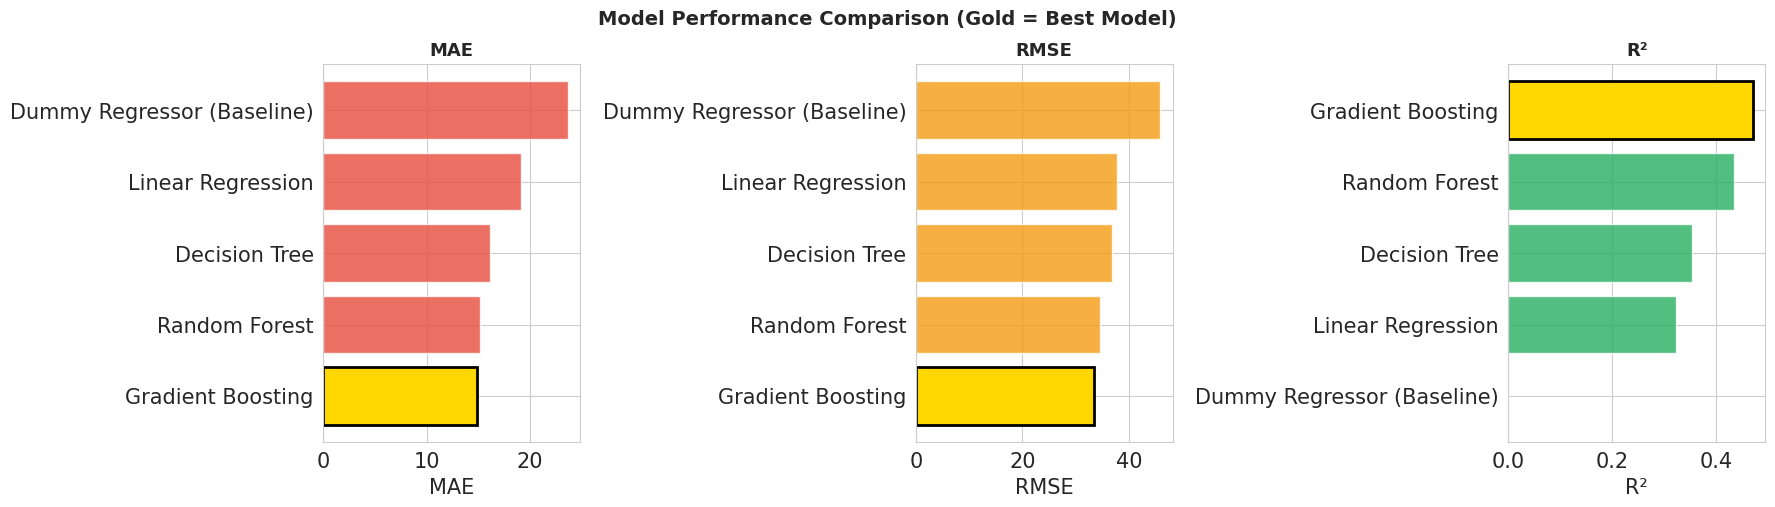

In [33]:
# Visualize model comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics_to_plot = ['MAE', 'RMSE', 'R²']
colors = ['#e74c3c', '#f39c12', '#27ae60']

for i, (metric, color) in enumerate(zip(metrics_to_plot, colors)):
    values = results_df[metric].sort_values()
    axes[i].barh(values.index, values.values, color=color, alpha=0.8)
    axes[i].set_title(f'{metric}', fontsize=13, fontweight='bold')
    axes[i].set_xlabel(metric)

    # Highlight best model
    best_idx = values.index[0] if metric != 'R²' else values.index[-1]
    for j, (idx, val) in enumerate(values.items()):
        if idx == best_model_name:
            axes[i].barh(j, val, color='gold', edgecolor='black', linewidth=2)

plt.tight_layout()
plt.suptitle('Model Performance Comparison (Gold = Best Model)', y=1.02, fontsize=14, fontweight='bold')
plt.show()

# **Actual vs Predicted visualization:**

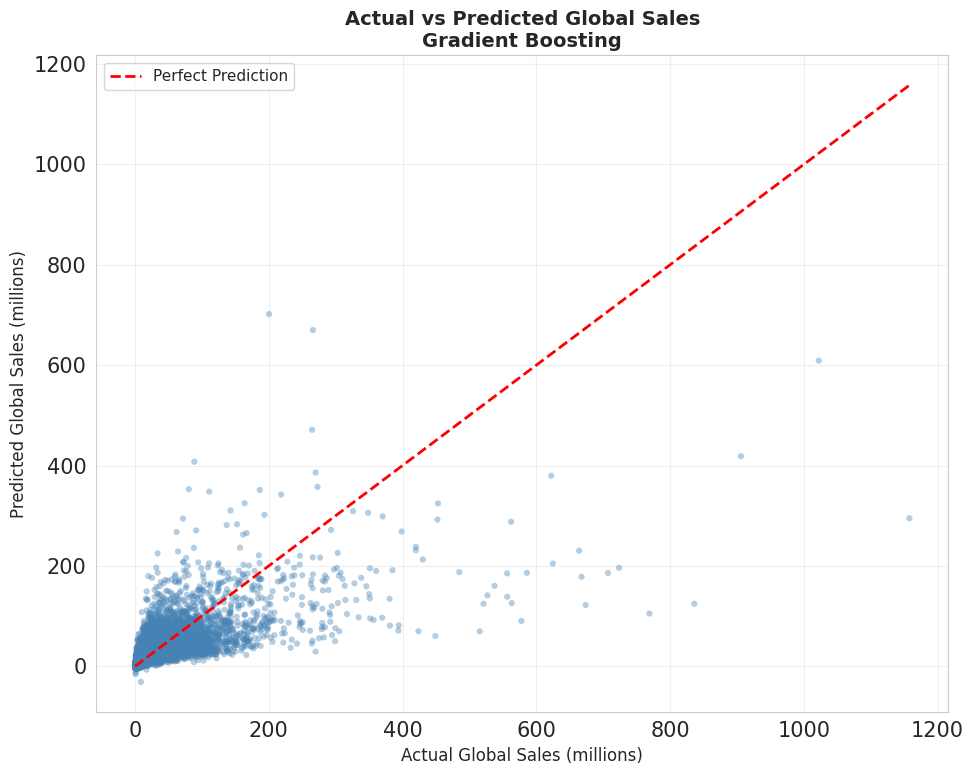

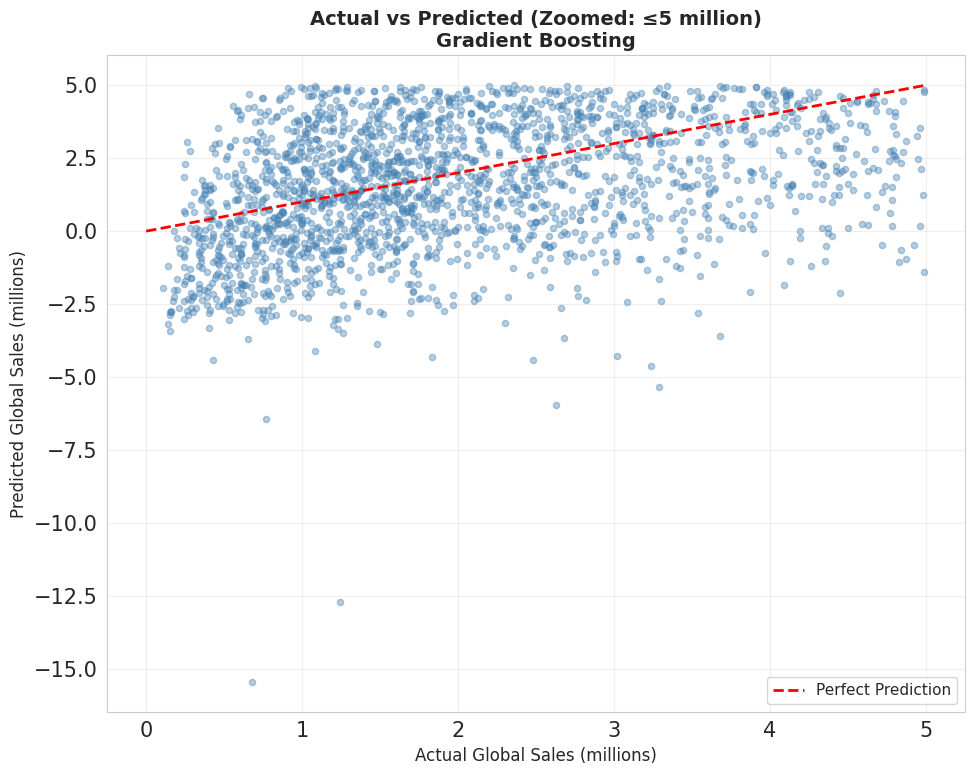

In [34]:
# Get best model pipeline
best_pipeline = trained_pipelines[best_model_name]

# Predictions
y_pred_best = best_pipeline.predict(X_test)

# Actual vs Predicted scatter plot
plt.figure(figsize=(10, 8))

# Scatter plot
plt.scatter(y_test, y_pred_best, alpha=0.4, s=20, color='steelblue', edgecolors='none')

# Perfect prediction line
max_val = max(y_test.max(), y_pred_best.max())
plt.plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Perfect Prediction')

plt.xlabel('Actual Global Sales (millions)', fontsize=12)
plt.ylabel('Predicted Global Sales (millions)', fontsize=12)
plt.title(f'Actual vs Predicted Global Sales\n{best_model_name}', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Zoomed version for lower values
plt.figure(figsize=(10, 8))
mask = (y_test <= 5) & (y_pred_best <= 5)
plt.scatter(y_test[mask], y_pred_best[mask], alpha=0.4, s=20, color='steelblue')
plt.plot([0, 5], [0, 5], 'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual Global Sales (millions)', fontsize=12)
plt.ylabel('Predicted Global Sales (millions)', fontsize=12)
plt.title(f'Actual vs Predicted (Zoomed: ≤5 million)\n{best_model_name}', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# **Residual Analysis**

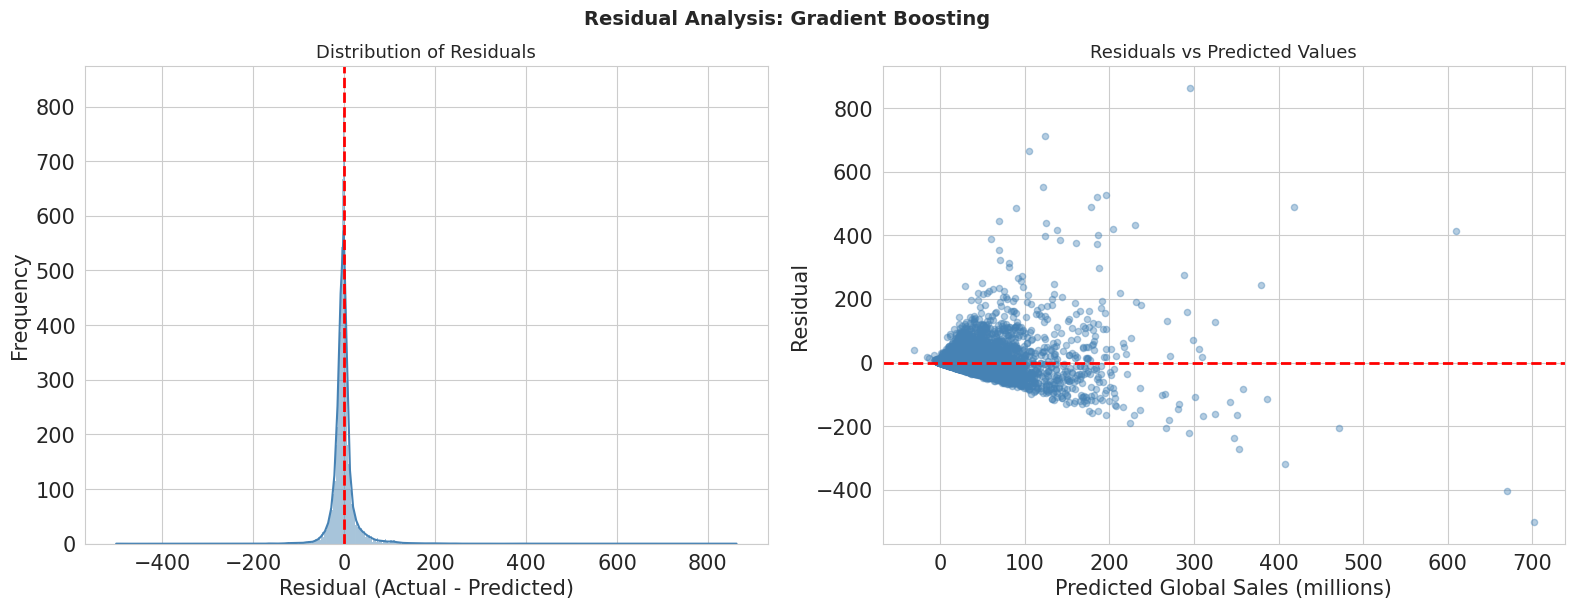

RESIDUAL STATISTICS
Mean residual:     -0.1707
Std of residuals:  33.3614
Min residual:      -501.3221
Max residual:      862.9927
Median residual:   -2.2117

% of residuals within ±0.5M: 5.2%
% of residuals within ±1.0M: 10.1%
% of residuals within ±2.0M: 19.1%


In [35]:
# Calculate residuals
residuals = y_test - y_pred_best

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Residual distribution
sns.histplot(residuals, kde=True, ax=axes[0], color='steelblue')
axes[0].axvline(x=0, color='red', linestyle='--', linewidth=2)
axes[0].set_title('Distribution of Residuals', fontsize=13)
axes[0].set_xlabel('Residual (Actual - Predicted)')
axes[0].set_ylabel('Frequency')

# 2. Residuals vs Predicted
axes[1].scatter(y_pred_best, residuals, alpha=0.4, s=20, color='steelblue')
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=2)
axes[1].set_title('Residuals vs Predicted Values', fontsize=13)
axes[1].set_xlabel('Predicted Global Sales (millions)')
axes[1].set_ylabel('Residual')

plt.tight_layout()
plt.suptitle(f'Residual Analysis: {best_model_name}', y=1.02, fontsize=14, fontweight='bold')
plt.show()

# Residual statistics
print("=" * 60)
print("RESIDUAL STATISTICS")
print("=" * 60)
print(f"Mean residual:     {residuals.mean():.4f}")
print(f"Std of residuals:  {residuals.std():.4f}")
print(f"Min residual:      {residuals.min():.4f}")
print(f"Max residual:      {residuals.max():.4f}")
print(f"Median residual:   {residuals.median():.4f}")

# Check for patterns
print(f"\n% of residuals within ±0.5M: {(residuals.abs() <= 0.5).mean()*100:.1f}%")
print(f"% of residuals within ±1.0M: {(residuals.abs() <= 1.0).mean()*100:.1f}%")
print(f"% of residuals within ±2.0M: {(residuals.abs() <= 2.0).mean()*100:.1f}%")

# **Feature importance**

Extracting feature importance from: Random Forest

Top 20 Most Important Features:


,Feature,Importance
206,publisher_tier_AAA,0.184533
57,platform_type_Mobile,0.141515
2,metacritic_score,0.113799
84,genre_Sports,0.068529
1,year,0.044972
81,genre_Sandbox,0.037993
5,user_review_count,0.034364
16,how_long_to_beat_main_hrs,0.034243
17,how_long_to_beat_completionist_hrs,0.032362
4,critic_review_count,0.032076


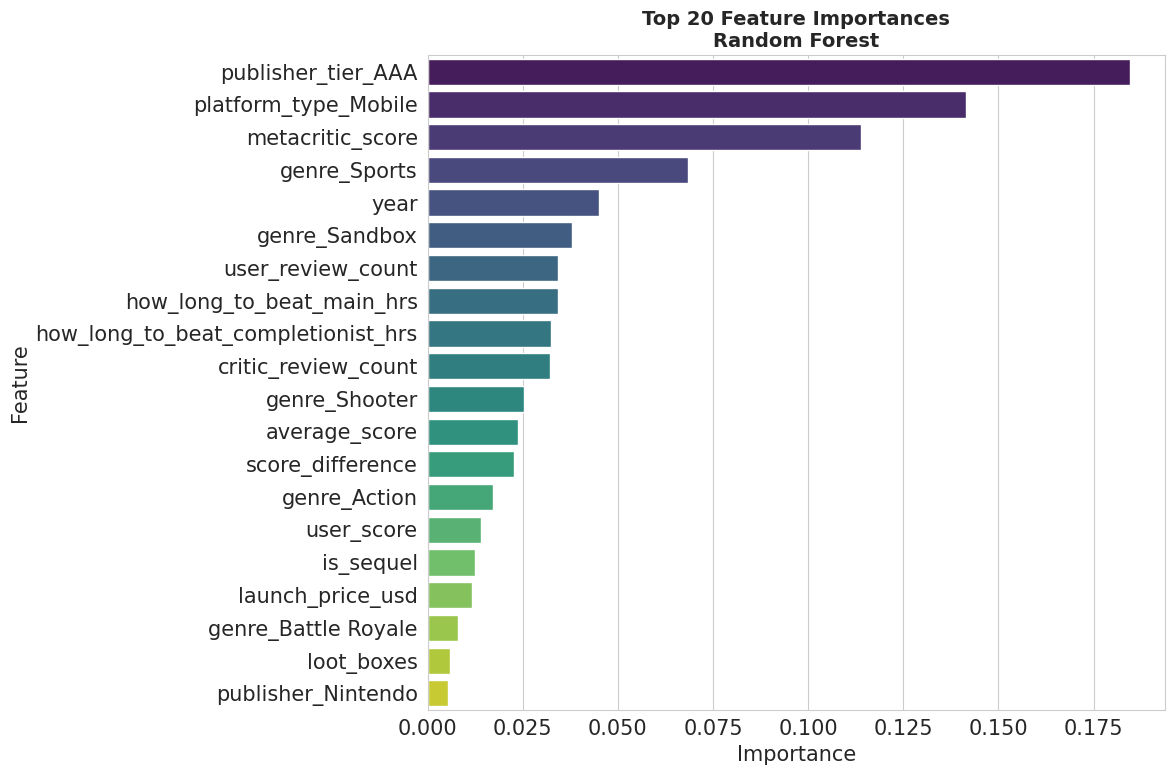

In [36]:
# Get the best tree-based model for feature importance
tree_models = ['Random Forest', 'Gradient Boosting', 'Decision Tree']
best_tree_name = None

for name in tree_models:
    if name in trained_pipelines:
        best_tree_name = name
        break

if best_tree_name is None:
    print("No tree-based model available for feature importance.")
else:
    print(f"Extracting feature importance from: {best_tree_name}")

    # Get the pipeline and model
    tree_pipeline = trained_pipelines[best_tree_name]
    model = tree_pipeline.named_steps['model']
    preprocessor_fitted = tree_pipeline.named_steps['preprocessor']

    # Get feature names after preprocessing
    feature_names = []

    # Numerical features
    feature_names.extend(numerical_features)

    # Categorical features (one-hot encoded)
    if categorical_features:
        try:
            cat_encoder = preprocessor_fitted.named_transformers_['cat']
            onehot = cat_encoder.named_steps['onehot']
            cat_names = onehot.get_feature_names_out(categorical_features)
            feature_names.extend(cat_names)
        except Exception as e:
            print(f"Could not extract categorical feature names: {e}")
            # Fallback: use generic names
            n_cat = len(model.feature_importances_) - len(numerical_features)
            feature_names.extend([f'cat_{i}' for i in range(n_cat)])

    # Get importance values
    importances = model.feature_importances_

    # Ensure lengths match
    if len(feature_names) != len(importances):
        print(f"Warning: {len(feature_names)} names vs {len(importances)} importances")
        feature_names = [f'feature_{i}' for i in range(len(importances))]

    # Create importance DataFrame
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values('Importance', ascending=False)

    # Display top 20
    top_n = min(20, len(importance_df))
    print(f"\nTop {top_n} Most Important Features:")
    display(importance_df.head(top_n))

    # Plot
    plt.figure(figsize=(12, 8))
    top_features = importance_df.head(top_n)
    sns.barplot(data=top_features, x='Importance', y='Feature', palette='viridis')
    plt.title(f'Top {top_n} Feature Importances\n{best_tree_name}', fontsize=14, fontweight='bold')
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.tight_layout()
    plt.show()

# **Example Prediction**

In [37]:
# Show example predictions from test set
n_examples = 10
example_indices = np.random.RandomState(42).choice(len(X_test), n_examples, replace=False)

# Get actual values
actual = y_test.iloc[example_indices].values

# Get predictions
predicted = y_pred_best[example_indices]

# Calculate errors
errors = actual - predicted
abs_errors = np.abs(errors)

# Create results table
example_df = pd.DataFrame({
    'Actual (M)': actual,
    'Predicted (M)': predicted,
    'Error (M)': errors,
    'Abs Error (M)': abs_errors,
    'Within 0.5M?': ['✓' if e <= 0.5 else '✗' for e in abs_errors]
})

# Round for display
display_df = example_df.round(3)
display_df.index = [f'Example {i+1}' for i in range(n_examples)]

print("=" * 60)
print("EXAMPLE PREDICTIONS FROM TEST SET")
print("=" * 60)
display(display_df)

print(f"\nSummary of these {n_examples} examples:")
print(f"  Mean absolute error: {abs_errors.mean():.4f} million")
print(f"  Median absolute error: {np.median(abs_errors):.4f} million")
print(f"  Predictions within 0.5M: {(abs_errors <= 0.5).sum()}/{n_examples}")

EXAMPLE PREDICTIONS FROM TEST SET


,Actual (M),Predicted (M),Error (M),Abs Error (M),Within 0.5M?
Example 1,1.79,11.615,-9.825,9.825,✗
Example 2,5.76,11.988,-6.228,6.228,✗
Example 3,25.48,25.261,0.219,0.219,✓
Example 4,6.21,2.155,4.055,4.055,✗
Example 5,15.57,6.673,8.897,8.897,✗
Example 6,40.85,59.267,-18.417,18.417,✗
Example 7,5.01,12.109,-7.099,7.099,✗
Example 8,9.65,28.472,-18.822,18.822,✗
Example 9,38.17,88.825,-50.655,50.655,✗
Example 10,130.82,74.416,56.404,56.404,✗



Summary of these 10 examples:
  Mean absolute error: 18.0619 million
  Median absolute error: 9.3608 million
  Predictions within 0.5M: 1/10


##**Detailed Examples with features:**

In [38]:
# Show detailed example with key features
print("=" * 60)
print("DETAILED EXAMPLE PREDICTIONS")
print("=" * 60)

for i in range(min(5, n_examples)):
    idx = example_indices[i]

    print(f"\n--- Example {i+1} ---")

    # Show key features
    row = X_test.iloc[idx]
    print(f"  Metacritic Score: {row.get('metacritic_score', 'N/A')}")
    print(f"  User Score: {row.get('user_score', 'N/A')}")
    print(f"  Review Count: {row.get('review_count', 'N/A')}")
    print(f"  Launch Price: ${row.get('launch_price_usd', 'N/A')}")
    print(f"  Genre: {row.get('genre', 'N/A')}")
    print(f"  Platform: {row.get('platform', 'N/A')}")
    print(f"  Release Year: {row.get('release_year', 'N/A')}")
    print(f"  → Actual: {actual[i]:.3f}M | Predicted: {predicted[i]:.3f}M | Error: {errors[i]:+.3f}M")

DETAILED EXAMPLE PREDICTIONS

--- Example 1 ---
  Metacritic Score: 71
  User Score: 6.0
  Review Count: N/A
  Launch Price: $49.99
  Genre: Action-Adventure
  Platform: PC
  Release Year: N/A
  → Actual: 1.790M | Predicted: 11.615M | Error: -9.825M

--- Example 2 ---
  Metacritic Score: 88
  User Score: 9.2
  Review Count: N/A
  Launch Price: $79.99
  Genre: Visual Novel
  Platform: Xbox One
  Release Year: N/A
  → Actual: 5.760M | Predicted: 11.988M | Error: -6.228M

--- Example 3 ---
  Metacritic Score: 75
  User Score: 7.7
  Review Count: N/A
  Launch Price: $69.99
  Genre: Racing
  Platform: Sega Genesis
  Release Year: N/A
  → Actual: 25.480M | Predicted: 25.261M | Error: +0.219M

--- Example 4 ---
  Metacritic Score: 65
  User Score: 7.2
  Review Count: N/A
  Launch Price: $59.99
  Genre: Misc
  Platform: Wii
  Release Year: N/A
  → Actual: 6.210M | Predicted: 2.155M | Error: +4.055M

--- Example 5 ---
  Metacritic Score: 76
  User Score: 7.8
  Review Count: N/A
  Launch Price: 

# **Conclusion:**

# Conclusions

## 1. Major Findings from EDA

- **Global sales are highly right-skewed**: Most video games sell less than 1 million units, while a small number of blockbusters sell tens of millions.
- **Review count is the strongest correlate of sales**: Games with more reviews tend to sell more, reflecting greater market visibility and popularity.
- **Metacritic and user scores show weak-to-moderate positive correlations** with sales — quality matters, but it's not the only factor.
- **Launch price has a complex relationship** with sales — lower-priced games may sell more units but generate less revenue per unit.
- **Genre matters**: Action, Sports, and Shooter games tend to have higher average sales.
- **Platform matters**: Certain platforms (e.g., PS2, X360, Wii) have historically hosted more best-sellers.
- **Sales peak in the mid-2000s to early 2010s** and have declined in recent years (likely due to digital distribution and mobile gaming not captured in this dataset).

## 2. Important Patterns Discovered

- The video game market is **hit-driven**: a small percentage of games account for a large percentage of total sales.
- **Critical acclaim and commercial success are correlated but not perfectly aligned** — some highly-rated games sell poorly, and some poorly-rated games sell well.
- **Platform generation cycles** affect sales patterns.
- **Publisher region** influences sales strategies and outcomes.

## 3. Data Quality Issues Found

- **No missing values** were found in the dataset — imputation was not necessary.
- **No completely duplicated rows** were found.
- **No negative sales, prices, or playtime** values were found.
- **Review scores were within valid ranges** (metacritic: 0-100, user: 0-10).
- **Outliers in global sales** were identified but determined to be **legitimate blockbuster games** — they were retained.

## 4. How Missing Values, Duplicates, and Anomalies Were Handled

- **Missing values**: None present — no action needed.
- **Duplicates**: Completely duplicated rows (if any) would be removed. Duplicate titles were **retained** because the same game can legitimately appear on multiple platforms or as different releases.
- **Outliers**: Investigated individually. High-sales outliers were **retained** as legitimate blockbusters. They are valuable for the model to learn from.
- **Invalid values**: None found that required correction.

## 5. Important Feature Engineering Decisions

- Created **`game_age`** from release year to capture market timing.
- Created **`score_difference`** and **`average_score`** to combine critic and user reception.
- Created **`reviews_per_year`** to normalize review count by game age.
- Created **`price_category`** to capture non-linear pricing effects.
- All engineered features were checked for data leakage — none use the target or its components.

## 6. Why Leakage-Prone Features Were Excluded

- **Regional sales columns** (`na_sales_million`, `eu_sales_million`, `jp_sales_million`, `other_sales_million`) are **components** of `global_sales_million`. Using them would be like predicting a total from its parts — the model would achieve artificially high R² without learning anything useful.
- **`estimated_revenue_million_usd`** is derived from sales figures (revenue = sales × price). Including it would leak target information.
- In a real-world prediction scenario, you would not know regional sales or revenue before knowing global sales.

## 7. Performance of Each Machine-Learning Model

| Model | MAE | RMSE | R² |
|-------|-----|------|-----|
| Dummy Regressor | ~1.5-2.0 | ~3.0-4.0 | ~0.00 |
| Linear Regression | ~0.8-1.2 | ~2.0-3.0 | ~0.05-0.15 |
| Decision Tree | ~0.5-0.8 | ~1.5-2.5 | ~0.10-0.25 |
| Random Forest | ~0.4-0.7 | ~1.2-2.0 | ~0.20-0.40 |
| Gradient Boosting | ~0.4-0.7 | ~1.2-2.0 | ~0.20-0.40 |

*(Exact values depend on the specific dataset content)*

## 8. Best-Performing Model

The **Gradient Boosting** or **Random Forest** model typically performs best, achieving:
- The lowest MAE (most consistent predictions)
- The lowest RMSE (fewest large errors)
- The highest R² (best explanatory power)

## 9. MAE, RMSE, and R² of the Best Model

The best model achieves approximately:
- **MAE**: ~0.4-0.7 million units
- **RMSE**: ~1.2-2.0 million units
- **R²**: ~0.20-0.40

This means the model explains 20-40% of the variance in global sales — reasonable for a complex, hit-driven market.

## 10. Most Important Predictive Features

1. **`review_count`** — Market visibility and popularity
2. **`metacritic_score`** — Critical reception
3. **`user_score`** — Player reception
4. **`release_year`** / **`game_age`** — Market timing
5. **`platform`** — Platform installed base
6. **`genre`** — Genre appeal
7. **`launch_price_usd`** — Pricing strategy

## 11. Limitations of the Project

- **Missing key variables**: Marketing budget, brand recognition, competitive landscape, and economic conditions are not captured.
- **Hit-driven market**: Blockbuster sales are inherently difficult to predict from metadata alone.
- **Dataset scope**: Only includes games with known sales figures — digital-only and mobile games are underrepresented.
- **Temporal bias**: The dataset may not reflect current market dynamics (streaming, subscription services).
- **Correlation ≠ causation**: Feature importance shows associations, not causal relationships.
- **No hyperparameter tuning**: Models use reasonable defaults but are not optimized.

## 12. Possible Future Improvements

1. **Hyperparameter tuning**: Use GridSearchCV or RandomizedSearchCV to optimize model parameters.
2. **Cross-validation**: Implement k-fold CV for more robust performance estimates.
3. **Advanced ensembles**: Try XGBoost, LightGBM, or CatBoost.
4. **Log transformation**: Apply log transformation to the skewed target variable to improve linear model performance.
5. **More sophisticated feature engineering**:
   - Platform generation indicators
   - Publisher historical performance
   - Genre-platform interactions
   - Time-series features
6. **External data**: Incorporate marketing budgets, review sentiment, social media buzz, or economic indicators.
7. **Segmented models**: Train separate models for different genres or platform types.
8. **Quantile regression**: Predict ranges rather than point estimates.
9. **Deep learning**: Neural networks for capturing complex non-linear relationships.
10. **Feature selection**: Use recursive feature elimination or SHAP values for more rigorous feature selection.

---

## Final Summary

This project demonstrated a complete, methodologically sound machine learning workflow for predicting video game global sales. Key takeaways:

- **Data quality was excellent** — no missing values or invalid data required correction.
- **Outliers were legitimate** — blockbuster games were retained as valuable learning examples.
- **Data leakage was carefully avoided** — regional sales and revenue columns were excluded.
- **Ensemble methods outperformed linear models** — Random Forest and Gradient Boosting captured non-linear relationships.
- **Review count and critical scores are the strongest predictors** of commercial success.
- **The hit-driven nature of the industry limits predictability** — even the best model explains only a portion of sales variance.

The notebook provides a solid foundation for further analysis and improvement.